/tmp/ipykernel_73546/2174515265.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("sign_model_augment.pth"))


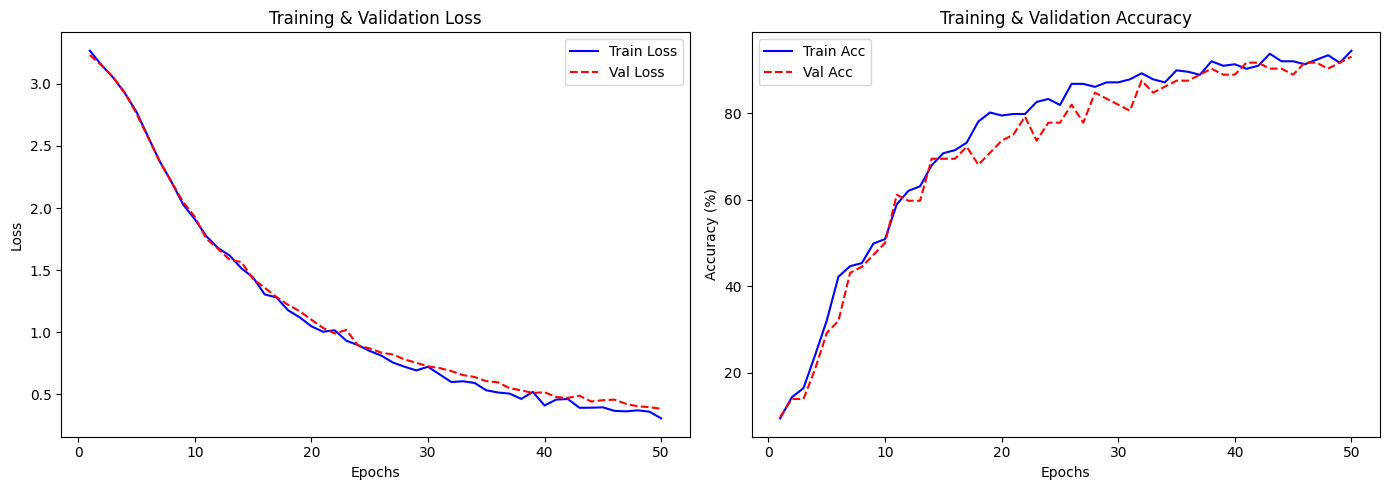

--- Classification Report ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00         2
         bad       1.00      1.00      1.00         2
     because       1.00      1.00      1.00         3
        bird       1.00      1.00      1.00         3
       black       1.00      0.67      0.80         3
       candy       1.00      0.50      0.67         2
      cousin       0.67      0.67      0.67         3
        deaf       0.75      1.00      0.86         3
   delicious       1.00      1.00      1.00         2
       drink       1.00      1.00      1.00         2
  government       1.00      1.00      1.00         3
         hot       1.00      1.00      1.00         2
        like       0.67      0.67      0.67         3
      mother       1.00      1.00      1.00         2
          no       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         3
       pizza       1.00      1.00      1.00        

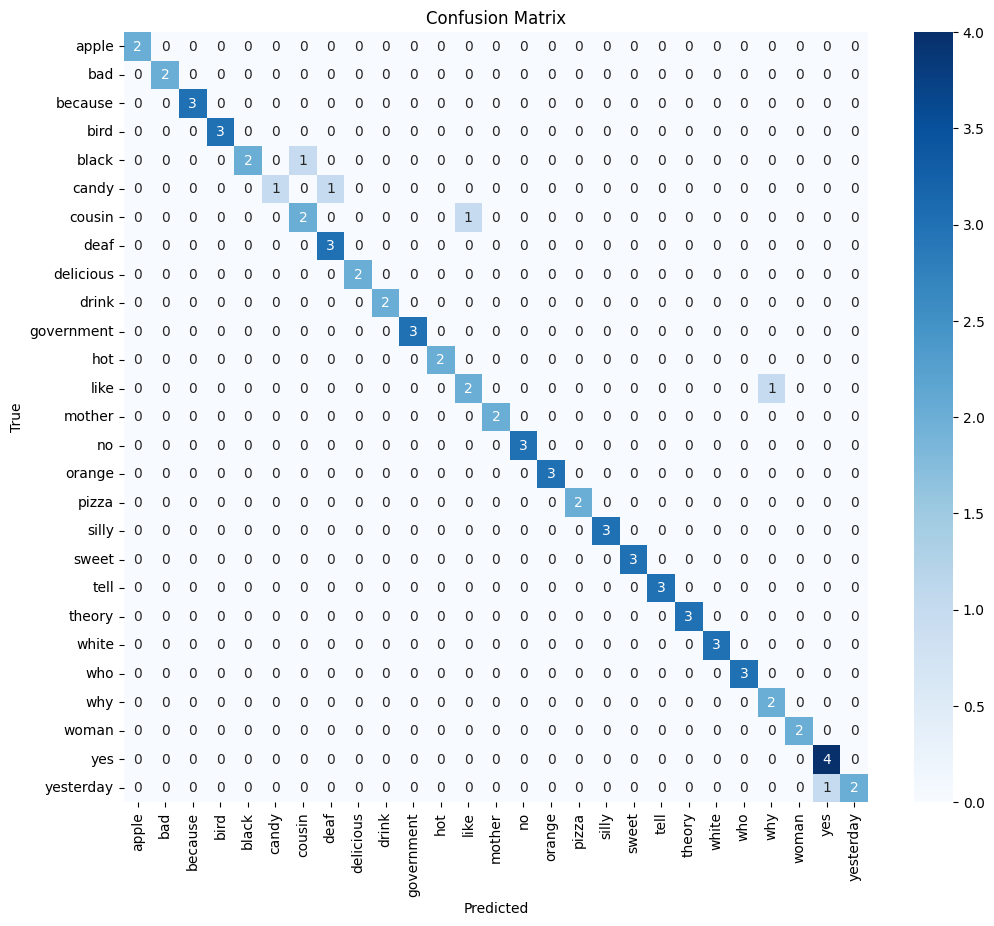

In [ ]:
# %% Block 1: Import
import torch
import torch.nn as nn
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import os
import glob

# Config phải khớp với train_pytorch.py
DATA_DIR = "dataset_processed"
SEQ_LEN = 30
INPUT_DIM = 63
HIDDEN_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# %% Block 2: Load Model & Data
# Load Class Names
with open("model_meta.json", "r") as f:
    meta = json.load(f)
    class_names = meta["labels"]

# Load Data (Test Set)
def load_data():
    X, y = [], []
    label_map = {lb: i for i, lb in enumerate(class_names)}
    for lb in class_names:
        files = glob.glob(os.path.join(DATA_DIR, lb, "*.npy"))
        for f in files:
            X.append(np.load(f))
            y.append(label_map[lb])
    return np.array(X), np.array(y)

X, y = load_data()
# Chia giống hệt lúc train để lấy tập Test
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Định nghĩa lại Model để load weight
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = GRUModel(INPUT_DIM, HIDDEN_SIZE, len(class_names)).to(DEVICE)
model.load_state_dict(torch.load("sign_model_augment.pth"))
model.eval()

# %% Block 3: Plot Training History
# Load history
if os.path.exists("training_history.json"):
    with open("training_history.json", "r") as f:
        history = json.load(f)

    epochs = range(1, len(history['loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r--', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r--', label='Val Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy file history!")

# %% Block 4: Confusion Matrix & Metrics
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

with torch.no_grad():
    outputs = model(X_test_tensor)
    _, preds = torch.max(outputs, 1)

preds = preds.cpu().numpy()
y_true = y_test_tensor.cpu().numpy()

# 1. Classification Report
print("--- Classification Report ---")
print(classification_report(y_true, preds, target_names=class_names))

# 2. Confusion Matrix
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()